In [1]:
import numpy as np 
import pandas as pd 
from datetime import datetime
import math 
import matplotlib.pyplot as plt
import datetime 

In [14]:
df = pd.read_csv("w_waypoints.csv")
df.head()

,time,.header.seq,.header.stamp.secs,.header.stamp.nsecs,.header.frame_id,.child_frame_id,.pose.pose.position.x,.pose.pose.position.y,.pose.pose.position.z,.pose.pose.orientation.x,...,.pose.pose.orientation.z,.pose.pose.orientation.w,.pose.covariance,.twist.twist.linear.x,.twist.twist.linear.y,.twist.twist.linear.z,.twist.twist.angular.x,.twist.twist.angular.y,.twist.twist.angular.z,.twist.covariance
0,2023/09/11/18:09:10.774613,25,3056,725540760,dlo_odom,base_link,-0.002436,0.001585,-0.001660,-0.016104,...,0.000063,0.999778,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0.0,0.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,2023/09/11/18:09:10.870874,26,3056,825536550,dlo_odom,base_link,-0.007002,0.001942,0.000412,-0.016097,...,-0.000058,0.999776,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0.0,0.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,2023/09/11/18:09:10.970917,27,3056,925638430,dlo_odom,base_link,-0.004030,0.000763,0.001094,-0.016281,...,0.000032,0.999775,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0.0,0.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,2023/09/11/18:09:11.073712,28,3057,25667070,dlo_odom,base_link,-0.006463,0.002159,-0.001094,-0.015819,...,0.000099,0.999779,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0.0,0.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,2023/09/11/18:09:11.173320,29,3057,125636960,dlo_odom,base_link,-0.009193,0.001218,-0.001460,-0.015755,...,0.000171,0.999788,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0.0,0.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [15]:
df.columns.values

array(['time', '.header.seq', '.header.stamp.secs', '.header.stamp.nsecs',
       '.header.frame_id', '.child_frame_id', '.pose.pose.position.x',
       '.pose.pose.position.y', '.pose.pose.position.z',
       '.pose.pose.orientation.x', '.pose.pose.orientation.y',
       '.pose.pose.orientation.z', '.pose.pose.orientation.w',
       '.pose.covariance', '.twist.twist.linear.x',
       '.twist.twist.linear.y', '.twist.twist.linear.z',
       '.twist.twist.angular.x', '.twist.twist.angular.y',
       '.twist.twist.angular.z', '.twist.covariance'], dtype=object)

In [16]:
df.rename(columns = {'.pose.pose.position.x':'PosX', '.pose.pose.position.y':'PosY' ,'.pose.pose.position.z':'PosZ' ,\
     '.pose.pose.orientation.x':'OrX','.pose.pose.orientation.y':'OrY','.pose.pose.orientation.z':'OrZ','.pose.pose.orientation.w':'OrW'}, inplace = True)
df.head()

,time,.header.seq,.header.stamp.secs,.header.stamp.nsecs,.header.frame_id,.child_frame_id,PosX,PosY,PosZ,OrX,...,OrZ,OrW,.pose.covariance,.twist.twist.linear.x,.twist.twist.linear.y,.twist.twist.linear.z,.twist.twist.angular.x,.twist.twist.angular.y,.twist.twist.angular.z,.twist.covariance
0,2023/09/11/18:09:10.774613,25,3056,725540760,dlo_odom,base_link,-0.002436,0.001585,-0.001660,-0.016104,...,0.000063,0.999778,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0.0,0.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,2023/09/11/18:09:10.870874,26,3056,825536550,dlo_odom,base_link,-0.007002,0.001942,0.000412,-0.016097,...,-0.000058,0.999776,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0.0,0.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,2023/09/11/18:09:10.970917,27,3056,925638430,dlo_odom,base_link,-0.004030,0.000763,0.001094,-0.016281,...,0.000032,0.999775,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0.0,0.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,2023/09/11/18:09:11.073712,28,3057,25667070,dlo_odom,base_link,-0.006463,0.002159,-0.001094,-0.015819,...,0.000099,0.999779,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0.0,0.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,2023/09/11/18:09:11.173320,29,3057,125636960,dlo_odom,base_link,-0.009193,0.001218,-0.001460,-0.015755,...,0.000171,0.999788,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.0,0.0,0.0,0.0,0.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [17]:
df.columns.values

array(['time', '.header.seq', '.header.stamp.secs', '.header.stamp.nsecs',
       '.header.frame_id', '.child_frame_id', 'PosX', 'PosY', 'PosZ',
       'OrX', 'OrY', 'OrZ', 'OrW', '.pose.covariance',
       '.twist.twist.linear.x', '.twist.twist.linear.y',
       '.twist.twist.linear.z', '.twist.twist.angular.x',
       '.twist.twist.angular.y', '.twist.twist.angular.z',
       '.twist.covariance'], dtype=object)

In [18]:
df.drop(['.header.seq', '.header.stamp.secs', '.header.stamp.nsecs','.header.frame_id' ,\
    '.child_frame_id', '.pose.covariance', '.twist.twist.linear.x',\
       '.twist.twist.linear.y', '.twist.twist.linear.z',\
       '.twist.twist.angular.x', '.twist.twist.angular.y',\
       '.twist.twist.angular.z', '.twist.covariance','OrX', 'OrY', 'OrZ', 'OrW','PosZ'], inplace=True, axis=1)
# df.drop(['PosZ', '.pose.pose.orientation.x', '.pose.pose.orientation.y', '.pose.pose.orientation.z',\
#        '.pose.pose.orientation.w'], inplace=True, axis=1)
df.head()

,time,PosX,PosY
0,2023/09/11/18:09:10.774613,-0.002436,0.001585
1,2023/09/11/18:09:10.870874,-0.007002,0.001942
2,2023/09/11/18:09:10.970917,-0.004030,0.000763
3,2023/09/11/18:09:11.073712,-0.006463,0.002159
4,2023/09/11/18:09:11.173320,-0.009193,0.001218


In [19]:
from datetime import datetime
df['time']= df['time'].apply(lambda x: datetime.strptime(x.strip(), '%Y/%m/%d/%H:%M:%S.%f'))
df['time']

0      2023-09-11 18:09:10.774613
1      2023-09-11 18:09:10.870874
2      2023-09-11 18:09:10.970917
3      2023-09-11 18:09:11.073712
4      2023-09-11 18:09:11.173320
                  ...            
1386   2023-09-11 18:11:29.376000
1387   2023-09-11 18:11:29.476802
1388   2023-09-11 18:11:29.578774
1389   2023-09-11 18:11:29.683055
1390   2023-09-11 18:11:29.782218
Name: time, Length: 1391, dtype: datetime64[ns]

In [20]:
df.head(5)

,time,PosX,PosY
0,2023-09-11 18:09:10.774613,-0.002436,0.001585
1,2023-09-11 18:09:10.870874,-0.007002,0.001942
2,2023-09-11 18:09:10.970917,-0.004030,0.000763
3,2023-09-11 18:09:11.073712,-0.006463,0.002159
4,2023-09-11 18:09:11.173320,-0.009193,0.001218


## Calculate the Velocity 

In [21]:
lastPx = 0 
lastPy = 0 
lastT = 0 
vMag = []
timeStamp = []
t = []
for idx , (currentT , currentPx, currentPy) in enumerate (zip(df.time ,df.PosX, df.PosY)):
    #if idx !=0:  
    currentT = currentT.timestamp() #- df.time[0].timestamp()
    # else:
        # currentT = 0 
    timeStamp.append((currentT)) # in mins
    t.append(currentT-timeStamp[0])
    dt = currentT-lastT
    # print(dt) 
    dx = currentPx - lastPx
    # print(dx)
    dy = currentPy - lastPy
    # print(dy)
    # try:
    currentVx = float(dx)/float(dt)
    # except:
        # print("division by Zero , 2lak ma henta ")
    currentVy = float(dy/dt) 
    
    vMag.append(math.sqrt(currentVx**2 + currentVy**2))
    lastT , lastPx  , lastPy  = currentT , currentPx  , currentPy 

df['Vmag'] = vMag
df['t'] = t
# print(t)

## Plot the Velocity Profile 

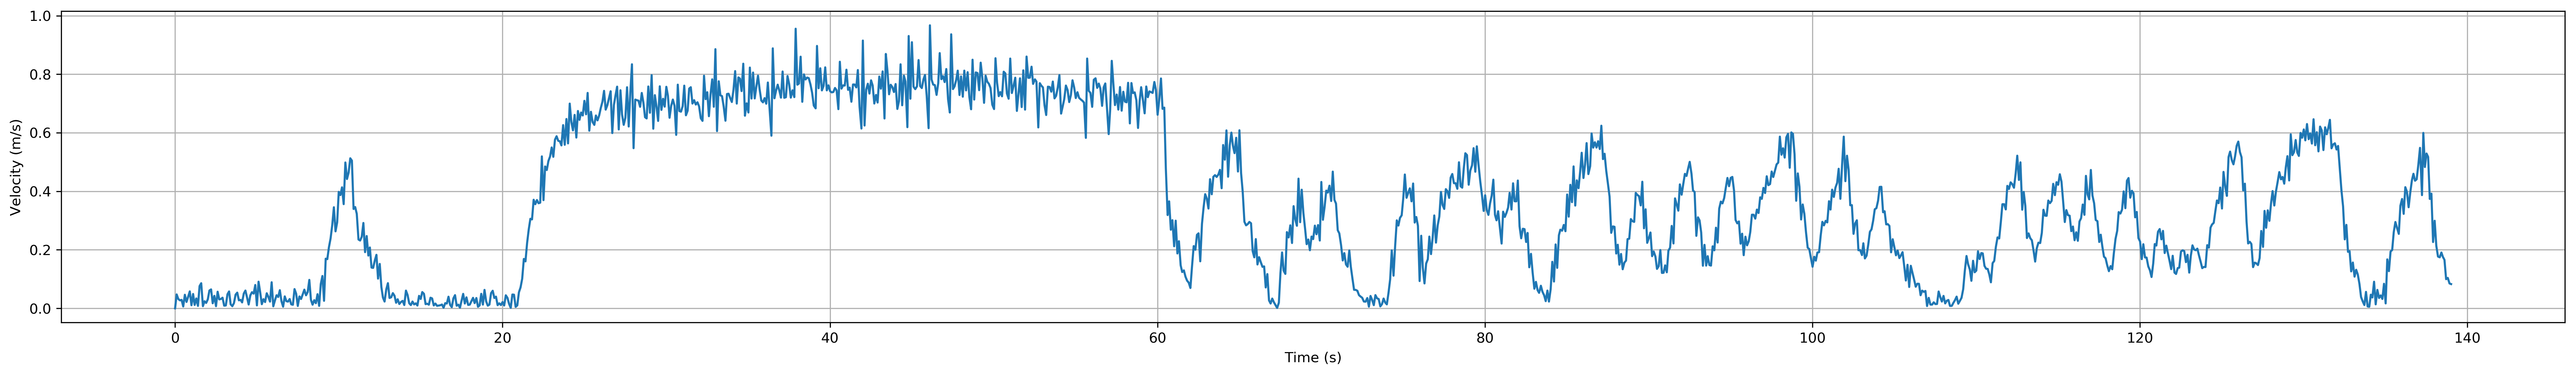

In [22]:
plt.figure(dpi=300, figsize=(32,4))
plt.grid()
# plt.xlim(0,51)
# plt.ylim(0,0.9)
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
# plt.xticks([40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100])
plt.plot(t, vMag)

## Filter the Velocity from T = 5.0 Sec and T =85.0 Sec 

In [23]:
df=df.loc[(df['t'] >= 20.0)]
df.reset_index(drop=True, inplace=True)
# df.head()
# df_new = df.iloc[df.t >= 0.0 and df.t <=51.0] 

## Plot Filtered Velocity Profile 

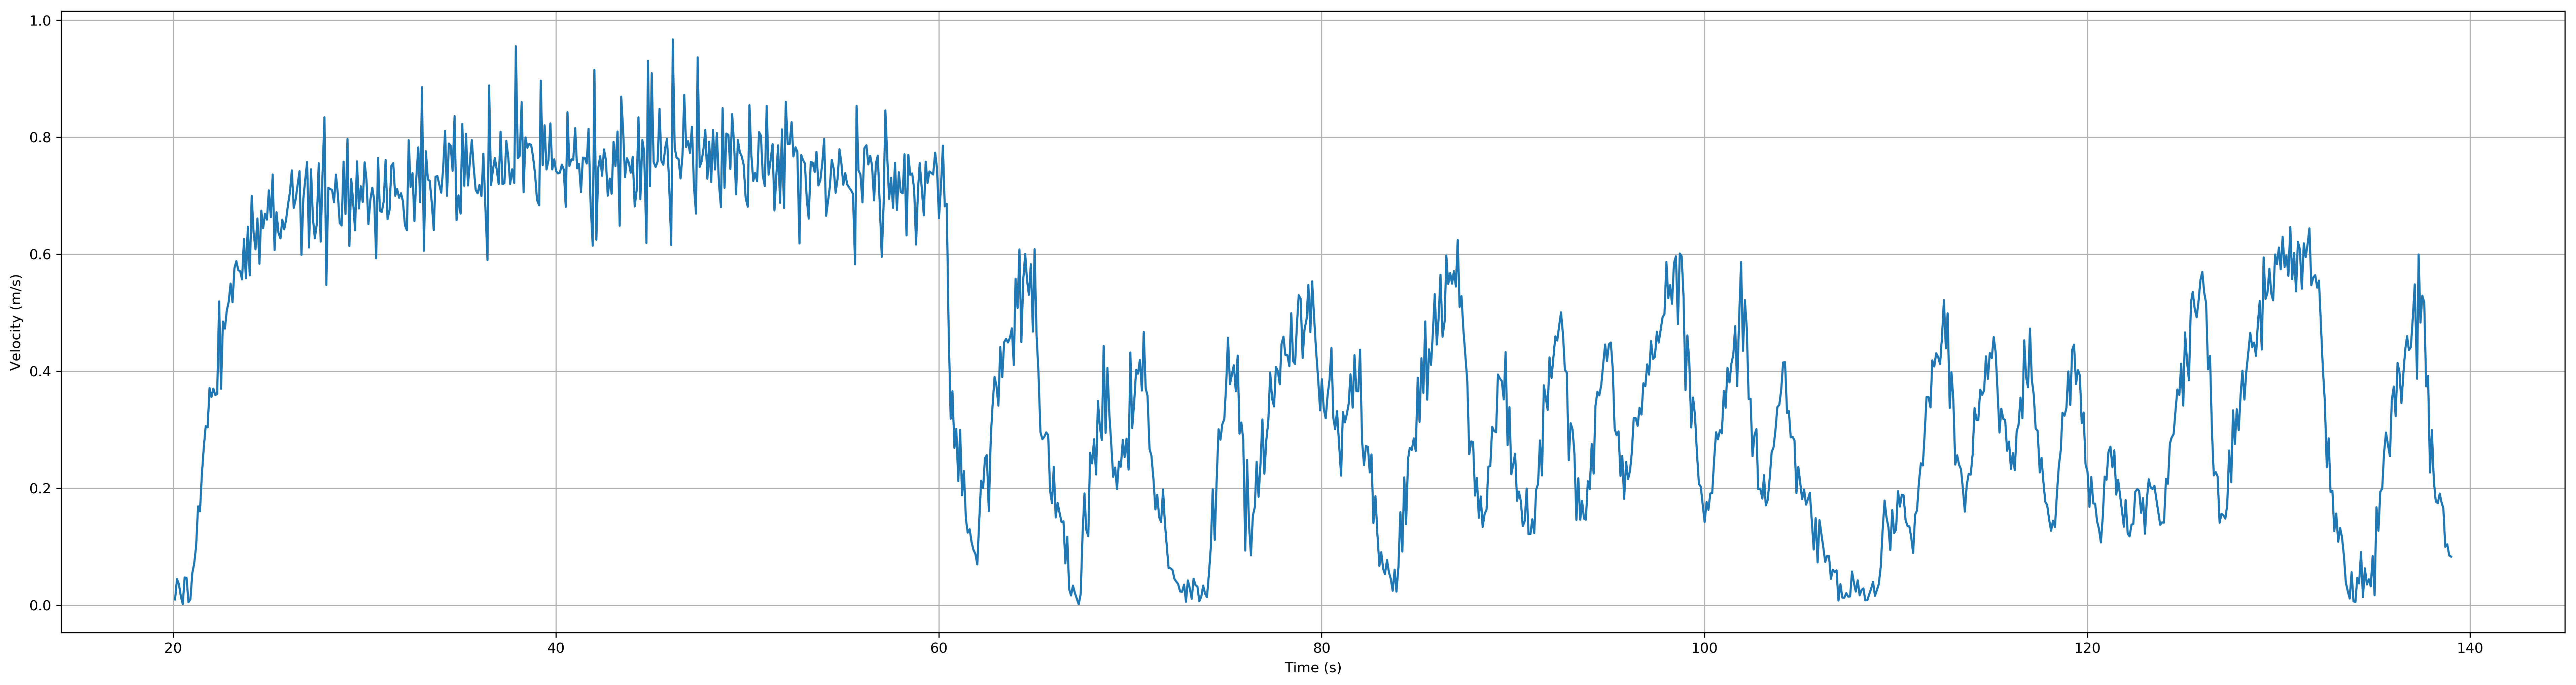

In [24]:
plt.figure(dpi=300, figsize=(32,8))
plt.grid()
# plt.xlim(5,84)
# plt.ylim(0,1.5)
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
# plt.xticks([40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100])
plt.plot(df.t, df.Vmag)

## Plot the Waypoints 

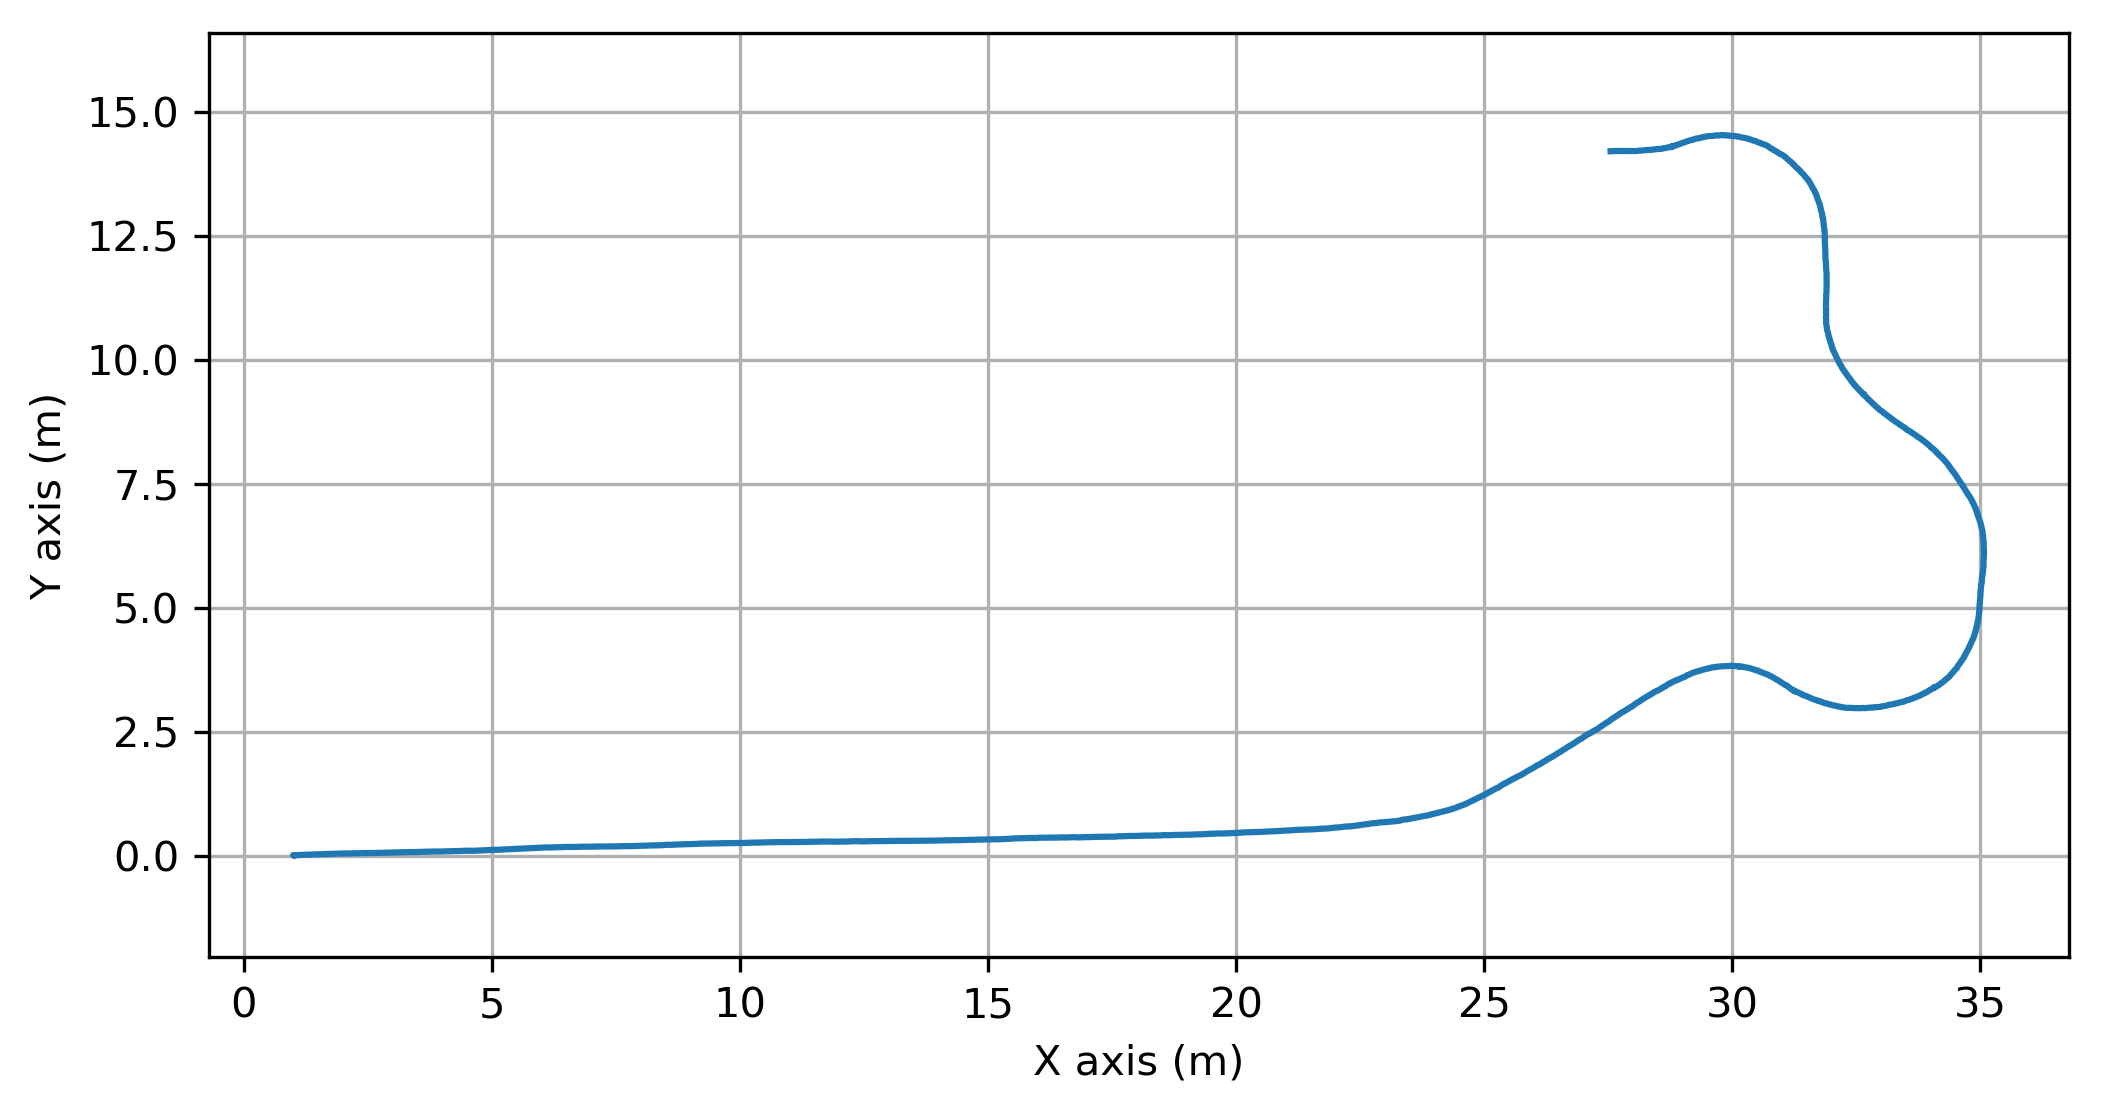

In [25]:
plt.figure(dpi=300, figsize=(8,4))
plt.grid()
plt.xlabel('X axis (m)')
plt.ylabel('Y axis (m)')
plt.axis('equal')
plt.plot(df.PosX , df.PosY)


In [26]:
carla_df = pd.DataFrame([df.PosX ,df.PosY , df.Vmag, df.t]).transpose()
carla_df.columns=['X','Y','V','Tway']
carla_df.Y = carla_df.Y
carla_df.Tway = carla_df.Tway - carla_df.Tway[0] 
# carla_df.X = carla_df.X - carla_df.X[0] 
# carla_df.Y = carla_df.Y - carla_df.Y[0] 
# carla_df.V = carla_df.V - carla_df.V[0] 
print(carla_df.columns.values)
print(carla_df.shape)
carla_df.head() 

['X' 'Y' 'V' 'Tway']
(1190, 4)


,X,Y,V,Tway
0,0.998570,0.013238,0.009757,0.000000
1,0.994536,0.015066,0.044531,0.099475
2,0.997676,0.013280,0.035934,0.200022
3,0.996567,0.014331,0.015239,0.300265
4,0.996397,0.014302,0.001712,0.401162


#### Build waypoints

In [28]:
# # sample_df = carla_df_avgV[start:finish]
# sample_df = carla_df[1:41]
# print(sample_df)
# print(sample_df.shape)
def avg_calc(sample):
  return sample.mean()
  
# x,y,v,t = avg_calc(sample= sample_df)
# print(x,y,v,t)

start = 0
increment = 15
finish = start + increment 
t_wp = []
x = []
y = []
v = []

x.append(carla_df.X[0])
y.append(carla_df.Y[0])
v.append(carla_df.V[0])
t_wp.append(0.0)
t_wp_0 = carla_df.Tway[0]

# print('    X\t\t      Y\t\t     V\t\t     T')
for i in range((carla_df.shape[0] - start)//increment):
    sample_df = carla_df[start:finish]
    xVal, yVal, vVal, tVal = avg_calc(sample= sample_df)
    x.append(xVal)
    y.append(yVal)
    v.append(vVal)
    t_wp.append(tVal-t_wp_0)
    
    # print(round(xVal,6),'\t',round(yVal,6),'\t',round(vVal,6),'\t',round(tVal-t_wp_0,6))

    start = finish
    finish += increment

# print((t_wp))
waypoints_df = pd.DataFrame()
waypoints_df['X'] = x
waypoints_df['Y'] = y
waypoints_df['V'] = v
waypoints_df['T'] = t_wp
# waypoints_df['V_avg'] = waypoints_df['V'].rolling(15).mean()
# waypoints_df.columns=['T','X','Y','V']
waypoints_df.shape

(120, 4)

In [134]:
# from math import nan

# for i in range(0,14):
#     waypoints_df['V_avg'][i] = waypoints_df['V_avg'][14]/13 * i
# waypoints_df['V_avg']

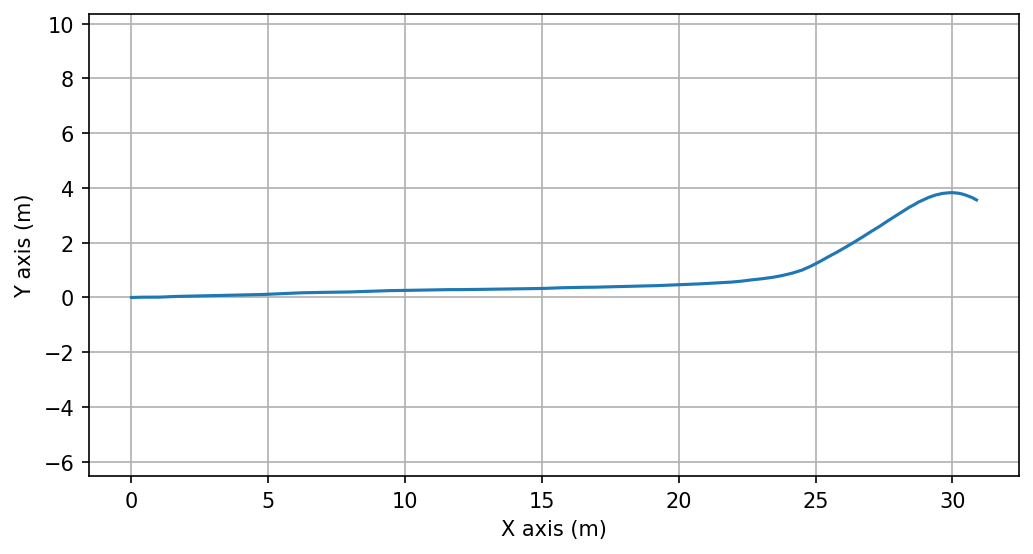

In [29]:
plt.figure(dpi=150, figsize=(8,4))
plt.grid()
plt.xlabel('X axis (m)')
plt.ylabel('Y axis (m)')
plt.axis('equal')
plt.plot(waypoints_df.X , waypoints_df.Y)

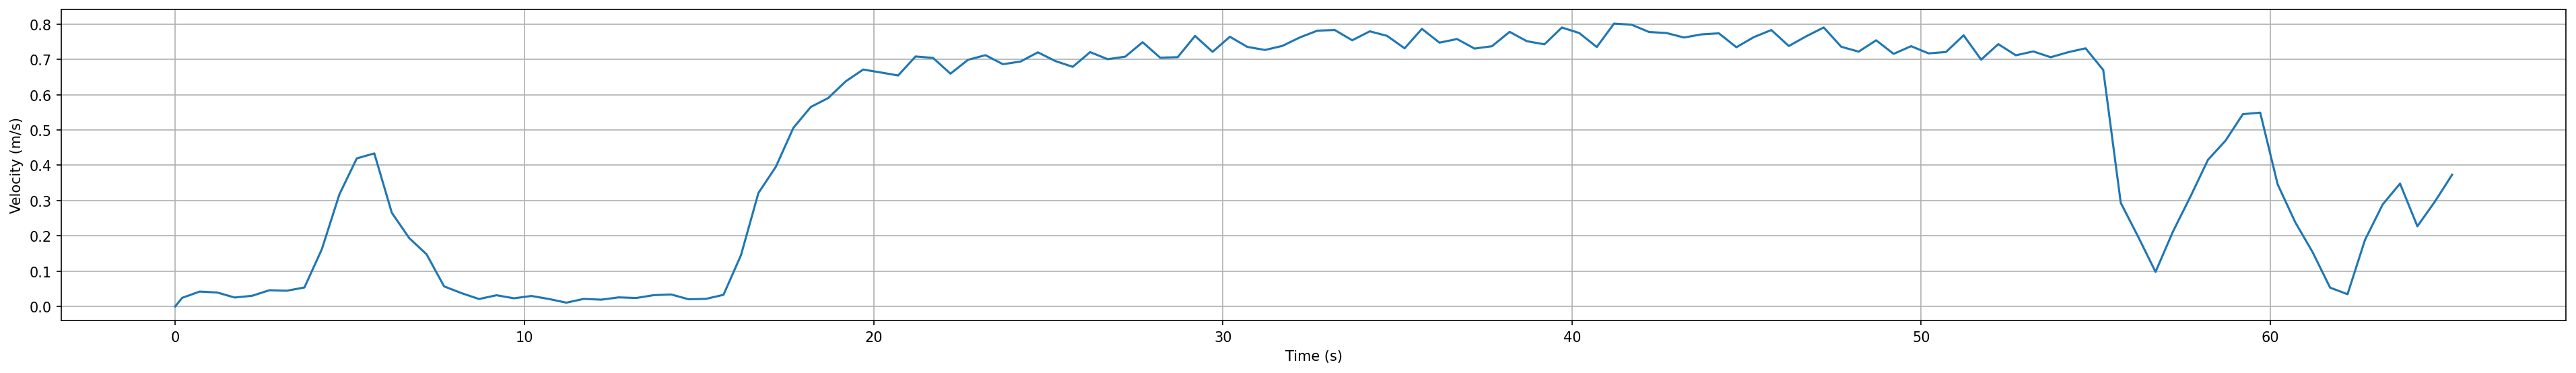

In [30]:
plt.figure(dpi=150, figsize=(32,4))
plt.grid()
# plt.xlim(39,102)
# plt.ylim(0,0.9)
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
# plt.xticks([40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100])
# plt.plot(t_wp, waypoints_df.V_avg)
plt.plot(t_wp, v)

#### This is to check when is the car going to move 

In [137]:
# df.index[(df['t'] >= 39.0) & (df['t']<=40.0)]
# for i in range(390,400):
#     print(df.iloc[i])

In [24]:
waypoints_df.head()

,X,Y,V,T
0,-0.001995,-0.000837,1.276600e-12,0.000000
1,-0.003916,-0.000828,2.432422e-02,0.199953
2,-0.005035,-0.000999,4.200970e-02,0.700163
3,-0.001699,0.000024,3.941069e-02,1.200188
4,-0.004095,-0.000496,2.520628e-02,1.700244


In [139]:
# waypoints_df.V = waypoints_df.V.mean()* 1.5
# waypoints_df.head()

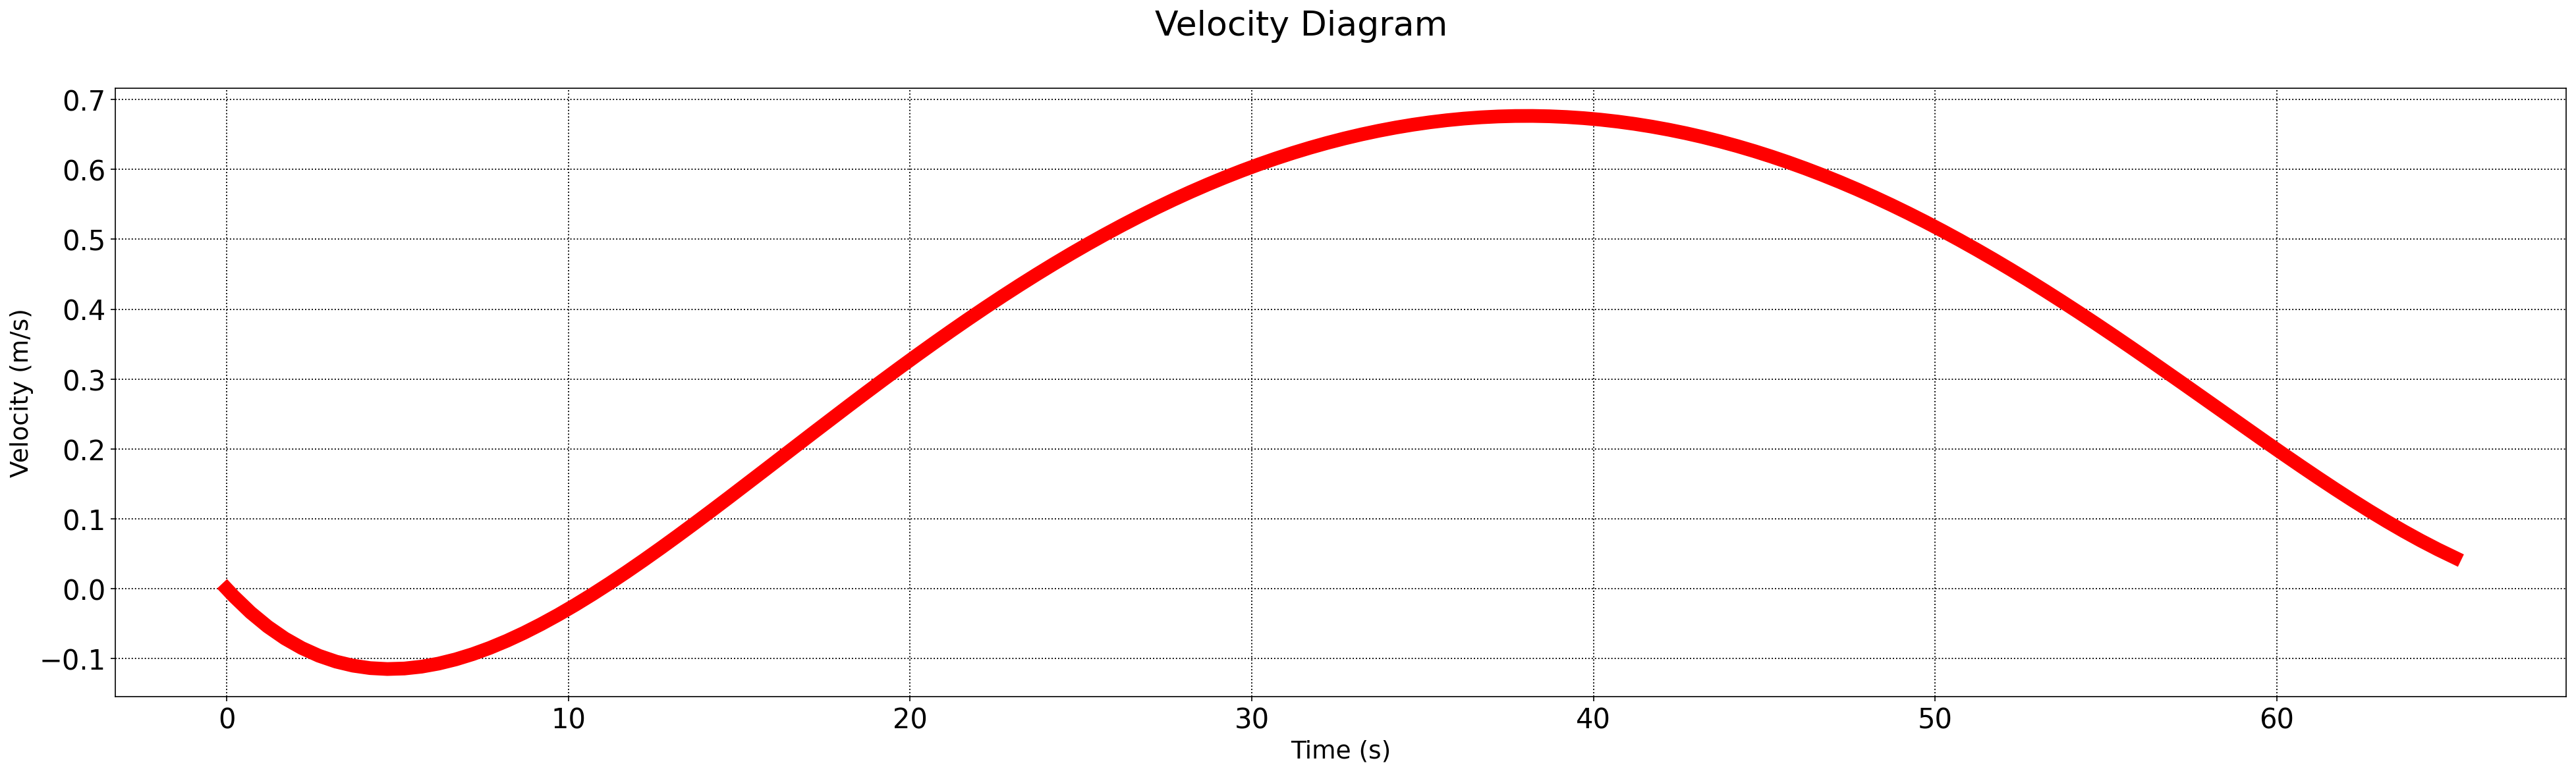

In [37]:
polyV = waypoints_df['V'].to_numpy()
polyT = waypoints_df['T'].to_numpy()
# print(polyT.shape)
V_polyfit = []
V_fcn = np.poly1d(np.polyfit(polyT , polyV,6))
for i in polyT:
    V_polyfit.append(V_fcn(i))
# print(V_fcn(t_wp[0]))
# print(V_polyfit)

plt.figure(dpi=150, figsize=(32,8))
plt.suptitle('Velocity Diagram', fontsize=25)
plt.grid(color = 'k', linestyle = ':', linewidth = 0.9)
# plt.xlim(0,65)
# plt.ylim(0,0.6)
plt.tick_params(axis='both', labelsize=20)

plt.xlabel('Time (s)',fontsize=18)
plt.ylabel('Velocity (m/s)',fontsize=18)

# plt.xticks([40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100])
# plt.plot(t_wp, waypoints_df.V_avg)
plt.plot(polyT, V_polyfit, color ='r',linewidth=10)

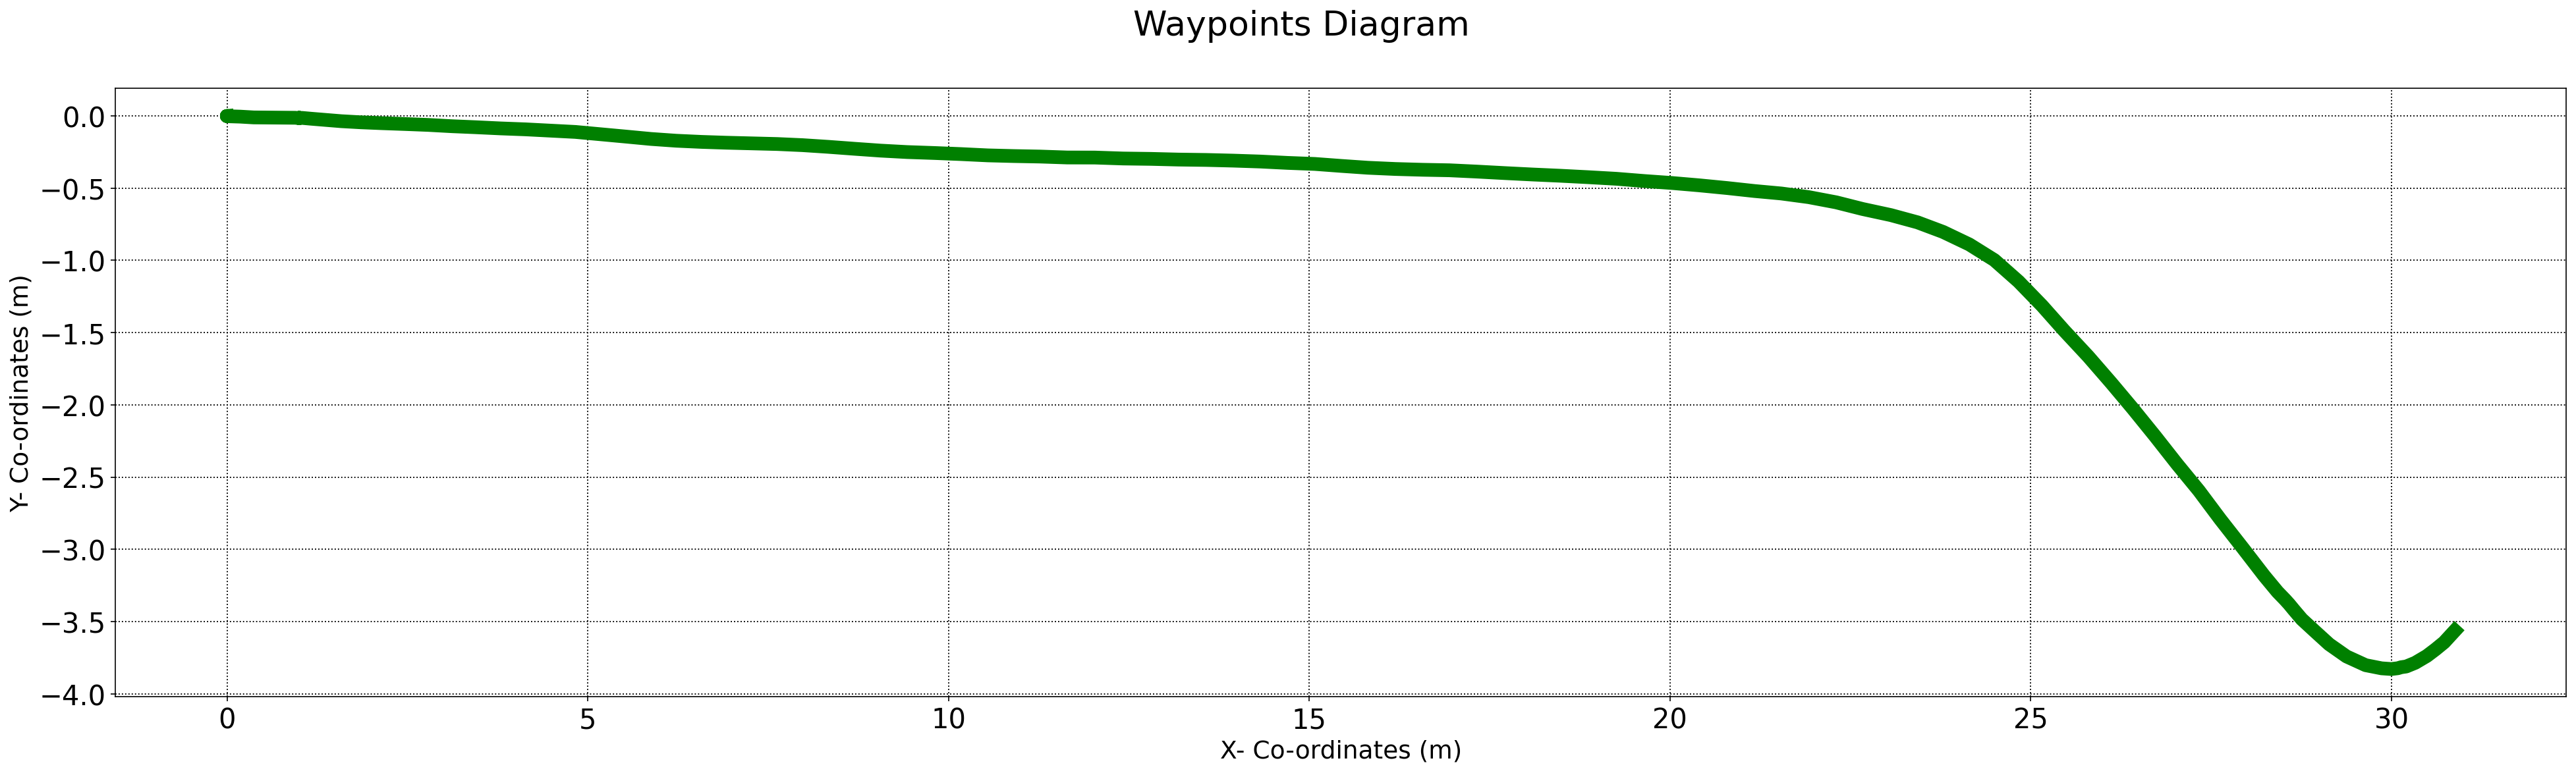

In [38]:
plt.figure(dpi=150, figsize=(32,8))
plt.suptitle('Waypoints Diagram', fontsize=25)
plt.grid(color = 'k', linestyle = ':', linewidth = 0.9)
plt.tick_params(axis='both', labelsize=20)
plt.xlabel('X- Co-ordinates (m)',fontsize=18)
plt.ylabel('Y- Co-ordinates (m)',fontsize=18)
plt.plot(waypoints_df.X , waypoints_df.Y *-1 , color= 'g', linewidth=10)

In [142]:
# t_wp

# polyTrack = waypoints_df.V.to_numpy()
# # print(polyTrack)
# Track_polyfit = []
# Track_fcn = np.poly1d(np.polyfit(t_wp , polyTrack,6))
# for i in t_wp:
#     V_polyfit.append(V_fcn(i))
# # print(V_fcn(t_wp[0]))
# # print(V_polyfit)

# plt.figure(dpi=150, figsize=(32,8))
# plt.suptitle('Velocity Diagram', fontsize=25)
# plt.grid(color = 'k', linestyle = ':', linewidth = 0.9)
# # plt.xlim(0,65)
# # plt.ylim(0,0.6)
# plt.tick_params(axis='both', labelsize=20)

# plt.xlabel('Time (s)',fontsize=18)
# plt.ylabel('Velocity (m/s)',fontsize=18)

# # plt.xticks([40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100])
# # plt.plot(t_wp, waypoints_df.V_avg)
# plt.plot(t_wp, V_polyfit, color ='r',linewidth=10)

In [143]:
# waypoints_df.shape

In [144]:
# waypoints_df.V =  V_polyfit
# waypoints_df.V *= 1.0
# finaldf = pd.DataFrame([waypoints_df.X ,waypoints_df.Y , waypoints_df.V]).transpose()
# finaldf.to_csv("racetrack_waypoints.txt", header=False,index=False)
# finaldf.head()

In [39]:
waypoints_df.V =  V_polyfit
waypoints_df.V -= waypoints_df.V[0]
finaldf = pd.DataFrame([waypoints_df.X, waypoints_df.Y, waypoints_df.V]).transpose()
finaldf.to_csv("w_test.csv", header=False, index=False)
print(finaldf.shape)
finaldf.head()

(132, 3)


,X,Y,V
0,-0.001995,0.000837,0.000000
1,-0.003916,0.000828,-0.010414
2,-0.005035,0.000999,-0.033954
3,-0.001699,-0.000024,-0.054063
4,-0.004095,0.000496,-0.070951


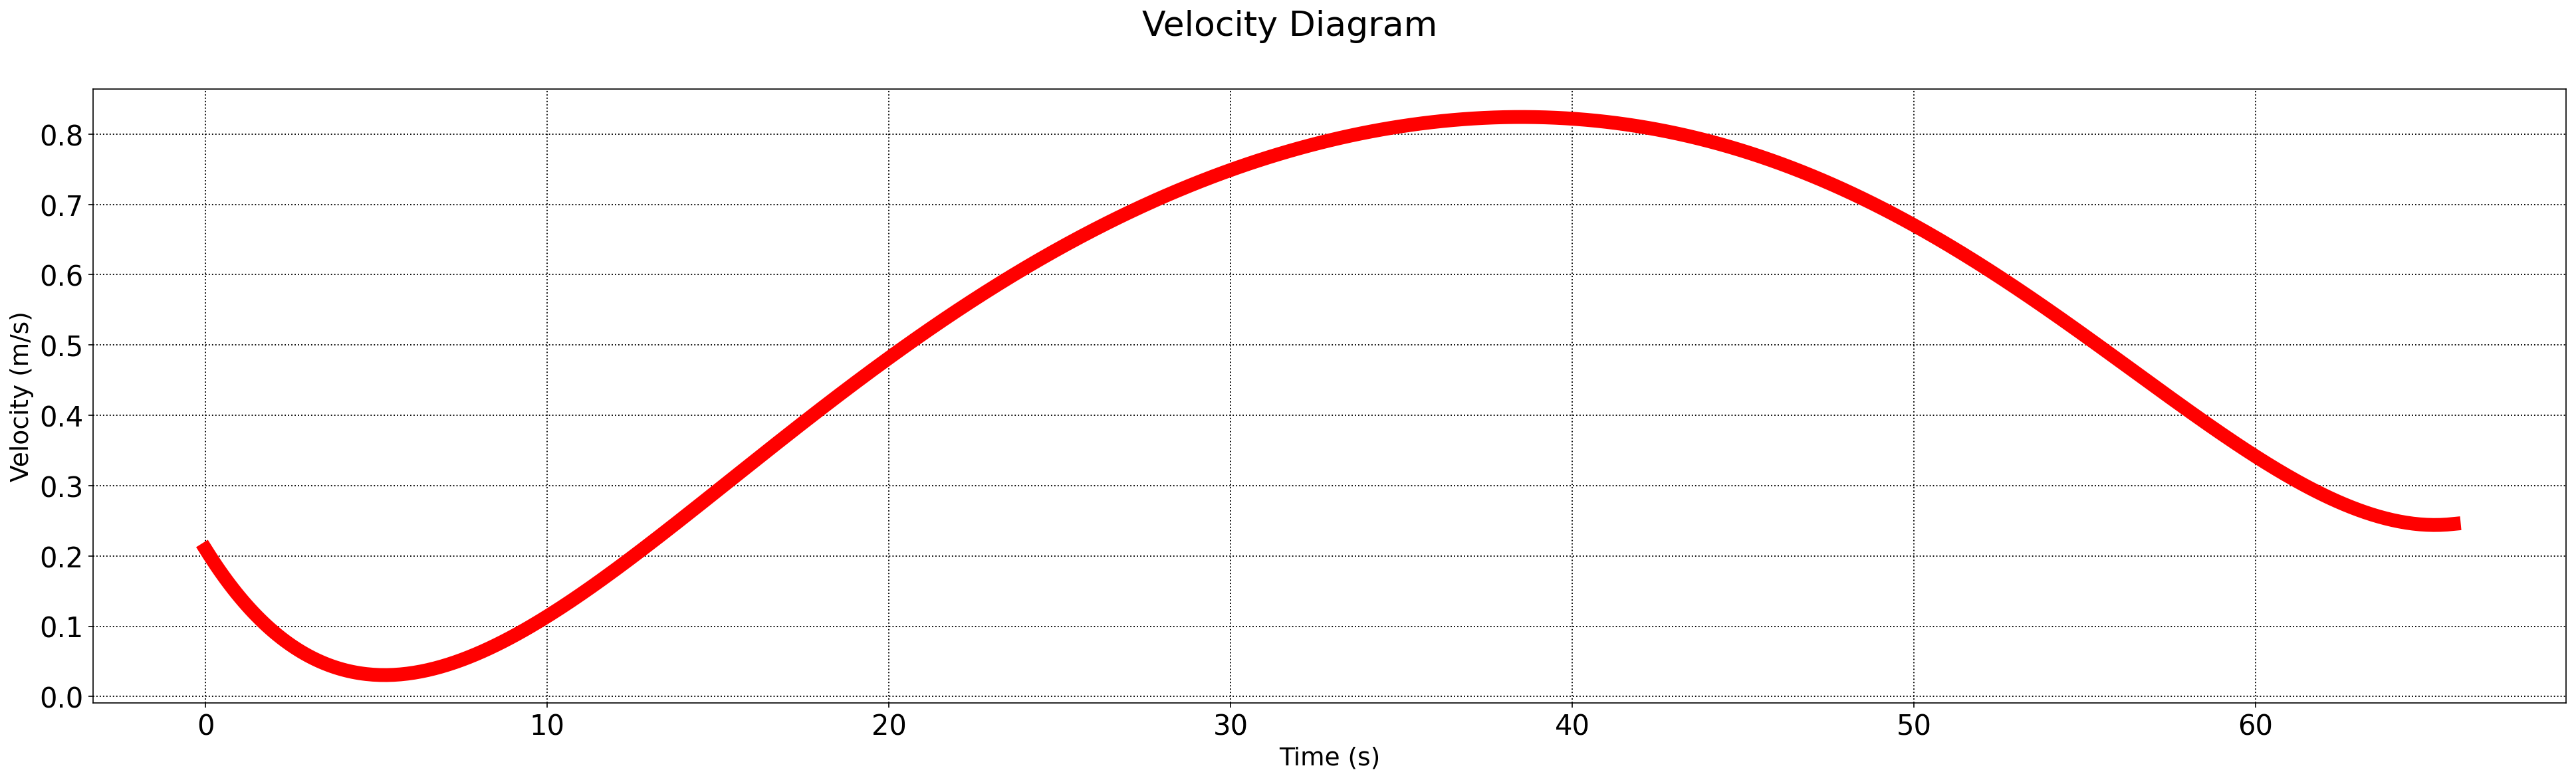

In [34]:
polyV = carla_df['V'].to_numpy()
polyT = carla_df['Tway'].to_numpy()
# print(polyT.shape)
V_polyfit = []
V_fcn = np.poly1d(np.polyfit(polyT , polyV,6))
for i in polyT:
    V_polyfit.append(V_fcn(i))
# print(V_fcn(t_wp[0]))
# print(V_polyfit)

plt.figure(dpi=150, figsize=(32,8))
plt.suptitle('Velocity Diagram', fontsize=25)
plt.grid(color = 'k', linestyle = ':', linewidth = 0.9)
# plt.xlim(0,65)
# plt.ylim(0,0.6)
plt.tick_params(axis='both', labelsize=20)

plt.xlabel('Time (s)',fontsize=18)
plt.ylabel('Velocity (m/s)',fontsize=18)

# plt.xticks([40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100])
plt.plot(polyT, V_polyfit, color ='r',linewidth=10)

In [35]:
carla_df.V =  V_polyfit
carla_df.V -= carla_df.V[0]
finaldf = pd.DataFrame([carla_df.X, carla_df.Y, carla_df.V]).transpose()
finaldf.to_csv("w_test.csv", header=False, index=False)
print(finaldf.shape)
finaldf.head()

(659, 3)


,X,Y,V
0,-0.001995,0.000837,0.000000
1,-0.007476,0.000749,-0.007743
2,-0.006065,0.000609,-0.015220
3,-0.003016,0.001351,-0.022547
4,-0.001029,0.000596,-0.029567


$E_{x} = (E_{x1} + E_{x2} \cdot df_{z} + E_{x3} \cdot df_{z}^{2}) \cdot (1 – E_{x4} \cdot \text{sgn}(k_{x}))$



$df_{z} = \frac{F_{z}-F_{z0}}{F_{z0}}$

$mu_{x} = D_{x1} + D_{x2} \cdot df_{z}$

$F_{z} = F_{z} \cdot D \cdot \sin \left ( C \cdot \arctan \left \{ B \cdot k – E \cdot \left [ B \cdot k – \arctan(B \cdot k) \right ] \right \} \right )$
